# SmartFeed Analytics

Notebook for demo charts. It logs in as the demo user, reads `/api/v1/analytics/me` and `/api/v1/analytics/global`, and builds plots for the project defense.

In [1]:
import json
import os
from urllib import request

import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

BACKEND_URL = os.getenv("BACKEND_URL", "http://backend:8000")
DEMO_EMAIL = os.getenv("DEMO_EMAIL", "demo@smartfeed.local")
DEMO_PASSWORD = os.getenv("DEMO_PASSWORD", "demo12345")

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 50)

def api_json(method, path, payload=None, token=None):
    data = None if payload is None else json.dumps(payload).encode("utf-8")
    headers = {"Content-Type": "application/json"}
    if token:
        headers["Authorization"] = f"Bearer {token}"
    req = request.Request(f"{BACKEND_URL}{path}", data=data, headers=headers, method=method)
    with request.urlopen(req, timeout=20) as response:
        return json.loads(response.read().decode("utf-8"))

auth = api_json("POST", "/api/v1/auth/login", {"email": DEMO_EMAIL, "password": DEMO_PASSWORD})
token = auth["access_token"]

personal = api_json("GET", "/api/v1/analytics/me", token=token)
global_stats = api_json("GET", "/api/v1/analytics/global", token=token)

personal, global_stats.keys()

({'source': 'mongo.raw_user_events',
  'favorite_categories': [{'category_id': 9,
    'category_name': 'Cloud',
    'score': 1.0,
    'events_count': 1,
    'views_count': 1,
    'likes_count': 0,
    'saves_count': 0}],
  'views_count': 1,
  'likes_count': 0,
  'saves_count': 0,
  'recommendations_opened': 0,
  'recommended_articles_opened': 0,
  'recommendation_ctr': 0.0},
 dict_keys(['source', 'top_categories', 'top_articles', 'events_by_type', 'activity_by_day', 'recommendations_opened', 'recommended_articles_opened', 'recommendation_ctr']))

## Events by day

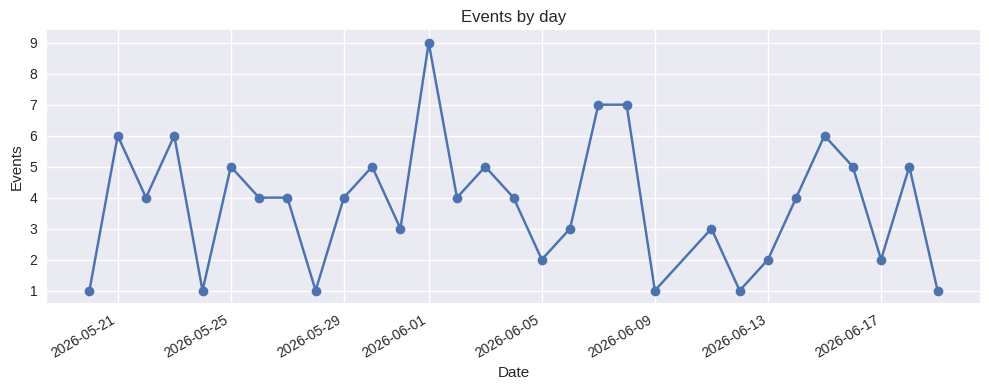

In [2]:
activity_df = pd.DataFrame(global_stats["activity_by_day"])
if activity_df.empty:
    print("No activity data yet. Run generator + Spark streaming first.")
else:
    activity_df["date"] = pd.to_datetime(activity_df["date"])
    ax = activity_df.plot(x="date", y="events_count", marker="o", figsize=(10, 4), legend=False)
    ax.set_title("Events by day")
    ax.set_xlabel("Date")
    ax.set_ylabel("Events")
    plt.tight_layout()

## Event type distribution

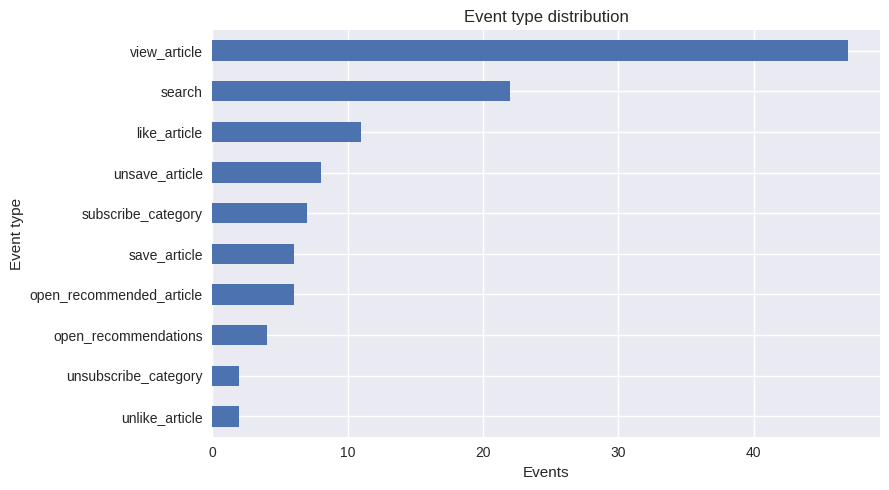

In [3]:
event_type_df = pd.DataFrame(global_stats["events_by_type"])
if event_type_df.empty:
    print("No event type data yet.")
else:
    event_type_df = event_type_df.sort_values("events_count", ascending=True)
    ax = event_type_df.plot.barh(x="event_type", y="events_count", figsize=(9, 5), legend=False)
    ax.set_title("Event type distribution")
    ax.set_xlabel("Events")
    ax.set_ylabel("Event type")
    plt.tight_layout()

## Top categories

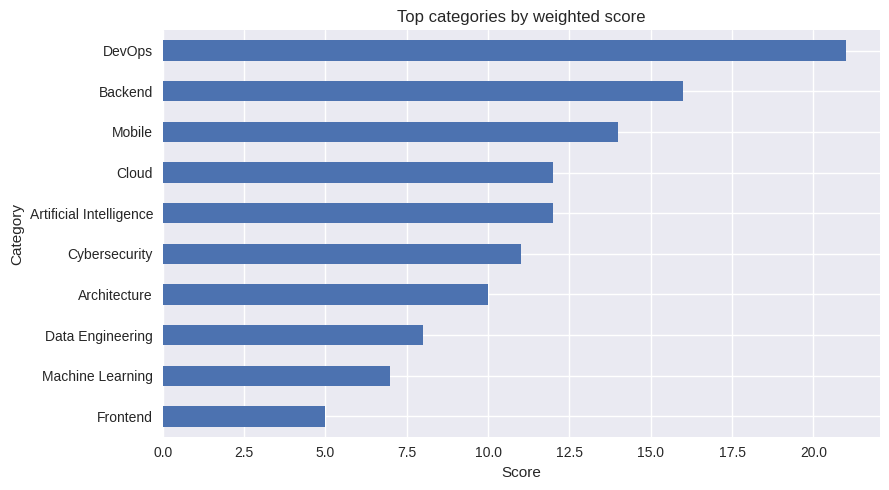

In [4]:
category_df = pd.DataFrame(global_stats["top_categories"])
if category_df.empty:
    print("No category analytics yet.")
else:
    category_df = category_df.sort_values("score", ascending=True)
    ax = category_df.plot.barh(x="category_name", y="score", figsize=(9, 5), legend=False)
    ax.set_title("Top categories by weighted score")
    ax.set_xlabel("Score")
    ax.set_ylabel("Category")
    plt.tight_layout()

## Recommendation CTR

,scope,recommendations_opened,recommended_articles_opened,ctr
0,personal,0,0,0.0
1,global,4,6,1.5


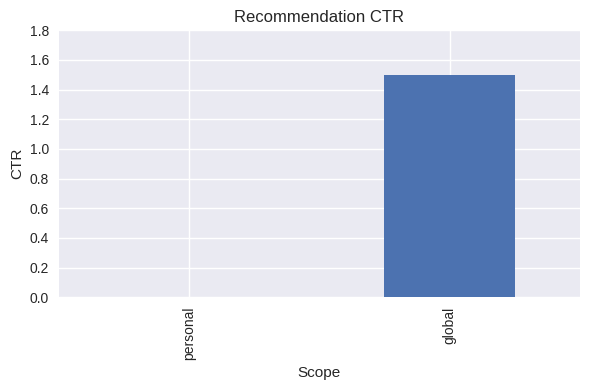

In [5]:
ctr_df = pd.DataFrame(
    [
        {
            "scope": "personal",
            "recommendations_opened": personal["recommendations_opened"],
            "recommended_articles_opened": personal["recommended_articles_opened"],
            "ctr": personal["recommendation_ctr"],
        },
        {
            "scope": "global",
            "recommendations_opened": global_stats["recommendations_opened"],
            "recommended_articles_opened": global_stats["recommended_articles_opened"],
            "ctr": global_stats["recommendation_ctr"],
        },
    ]
)
display(ctr_df)

ax = ctr_df.plot.bar(x="scope", y="ctr", ylim=(0, max(0.1, ctr_df["ctr"].max() * 1.2)), figsize=(6, 4), legend=False)
ax.set_title("Recommendation CTR")
ax.set_xlabel("Scope")
ax.set_ylabel("CTR")
plt.tight_layout()